In [1]:
import pandas as pd
import numpy as np
import os

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("DatasetSKillGap.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (1000, 48)


,REG_Number,Department,Graduation_Year,CGPA,Internship,Internship_Months,Projects_Count,Certifications_Count,Python_Skill,SQL_Skill,...,Operating_Systems_Gap,Web_Development_Gap,Cloud_Computing_Gap,Machine_Learning_Gap,Communication_Gap,Problem_Solving_Gap,Overall_Skill_Gap,Skill_Alignment_Percentage,Placement_Status,event_timestamp
0,231FA04001,CSE,2027,7.78,No,0,5,3,6.2,4.7,...,0.0,0.2,0.0,1.0,2.3,2.7,1.22,87.8,Placed,2026-01-01 00:00:00
1,231FA04002,CSE-DS,2027,6.65,Yes,8,1,3,6.9,4.9,...,0.8,0.0,3.0,1.2,1.2,1.7,1.80,82.0,Placed,2026-01-01 06:00:00
2,231FA04003,CSE-AIML,2027,7.94,Yes,10,4,2,5.3,7.7,...,2.1,0.0,0.0,0.2,2.9,1.8,1.28,87.2,Placed,2026-01-01 12:00:00
3,231FA04004,CSE-AIML,2027,8.11,Yes,3,2,2,6.4,5.5,...,0.5,0.0,0.0,0.0,1.9,0.0,0.91,90.9,Placed,2026-01-01 18:00:00
4,231FA04005,CSE,2027,8.07,Yes,2,3,4,9.0,7.8,...,1.5,0.0,0.0,0.6,0.0,1.0,0.41,95.9,Not Placed,2026-01-02 00:00:00


In [3]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
REG_Number
Department
Graduation_Year
CGPA
Internship
Internship_Months
Projects_Count
Certifications_Count
Python_Skill
SQL_Skill
DSA_Skill
DBMS_Skill
OOP_Skill
Computer_Networks_Skill
Operating_Systems_Skill
Web_Development_Skill
Cloud_Computing_Skill
Machine_Learning_Skill
Communication_Skill
Problem_Solving_Skill
Industry_Python_Required
Industry_SQL_Required
Industry_DSA_Required
Industry_DBMS_Required
Industry_OOP_Required
Industry_Computer_Networks_Required
Industry_Operating_Systems_Required
Industry_Web_Development_Required
Industry_Cloud_Computing_Required
Industry_Machine_Learning_Required
Industry_Communication_Required
Industry_Problem_Solving_Required
Python_Gap
SQL_Gap
DSA_Gap
DBMS_Gap
OOP_Gap
Computer_Networks_Gap
Operating_Systems_Gap
Web_Development_Gap
Cloud_Computing_Gap
Machine_Learning_Gap
Communication_Gap
Problem_Solving_Gap
Overall_Skill_Gap
Skill_Alignment_Percentage
Placement_Status
event_timestamp


In [4]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   REG_Number                           1000 non-null   object 
 1   Department                           1000 non-null   object 
 2   Graduation_Year                      1000 non-null   int64  
 3   CGPA                                 1000 non-null   float64
 4   Internship                           1000 non-null   object 
 5   Internship_Months                    1000 non-null   int64  
 6   Projects_Count                       1000 non-null   int64  
 7   Certifications_Count                 1000 non-null   int64  
 8   Python_Skill                         1000 non-null   float64
 9   SQL_Skill                            1000 non-null   float64
 10  DSA_Skill                            1000 non-null   float64
 11  DBMS_Skil

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
REG_Number                             0
Department                             0
Graduation_Year                        0
CGPA                                   0
Internship                             0
Internship_Months                      0
Projects_Count                         0
Certifications_Count                   0
Python_Skill                           0
SQL_Skill                              0
DSA_Skill                              0
DBMS_Skill                             0
OOP_Skill                              0
Computer_Networks_Skill                0
Operating_Systems_Skill                0
Web_Development_Skill                  0
Cloud_Computing_Skill                  0
Machine_Learning_Skill                 0
Communication_Skill                    0
Problem_Solving_Skill                  0
Industry_Python_Required               0
Industry_SQL_Required                  0
Industry_DSA_Required                  0
Industry_DBMS_Required                 0

In [6]:
print("event_timestamp exists:",
      "event_timestamp" in df.columns)

event_timestamp exists: True


In [7]:
df["event_timestamp"] = pd.to_datetime(
    df["event_timestamp"]
)

print(df["event_timestamp"].dtype)

datetime64[ns]


In [8]:
skill_gap_columns = [
    "Python_Gap",
    "SQL_Gap",
    "DSA_Gap",
    "DBMS_Gap",
    "OOP_Gap",
    "Computer_Networks_Gap",
    "Operating_Systems_Gap",
    "Web_Development_Gap",
    "Cloud_Computing_Gap",
    "Machine_Learning_Gap",
    "Communication_Gap",
    "Problem_Solving_Gap"
]

# Number of high-priority skill gaps
df["High_Priority_Gap_Count"] = (
    df[skill_gap_columns] >= 3
).sum(axis=1)

# Employability score
df["Employability_Score"] = (
    0.40 * df["Skill_Alignment_Percentage"] +
    0.20 * (df["CGPA"] / 10 * 100) +
    0.20 * (df["Projects_Count"] / 7 * 100) +
    0.20 * (df["Internship_Months"] / 12 * 100)
).round(2)

print("Feature engineering completed.")

Feature engineering completed.


In [9]:
df[
    [
        "REG_Number",
        "CGPA",
        "Overall_Skill_Gap",
        "Skill_Alignment_Percentage",
        "High_Priority_Gap_Count",
        "Employability_Score",
        "Placement_Status"
    ]
].head(10)

,REG_Number,CGPA,Overall_Skill_Gap,Skill_Alignment_Percentage,High_Priority_Gap_Count,Employability_Score,Placement_Status
0,231FA04001,7.78,1.22,87.8,1,64.97,Placed
1,231FA04002,6.65,1.80,82.0,3,62.29,Placed
2,231FA04003,7.94,1.28,87.2,0,78.86,Placed
3,231FA04004,8.11,0.91,90.9,0,63.29,Placed
4,231FA04005,8.07,0.41,95.9,0,66.40,Not Placed
5,231FA04006,8.46,0.83,91.7,0,84.55,Placed
6,231FA04007,8.28,0.88,91.2,1,73.99,Placed
7,231FA04008,7.99,0.82,91.8,1,75.32,Placed
8,231FA04009,7.60,1.03,89.7,1,76.79,Not Placed
9,231FA04010,6.40,0.91,90.9,0,66.78,Placed


In [10]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\bakka\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [11]:
df.to_parquet(
    "feature_data.parquet",
    engine="pyarrow",
    index=False
)

print("feature_data.parquet created successfully!")

feature_data.parquet created successfully!


In [12]:
print(os.listdir())

['.ipynb_checkpoints', 'Assignment_MLOPS_A91.ipynb', 'DatasetSKillGap.csv', 'feature_data.parquet']


In [13]:
%pip install feast

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.2
    Uninstalling numpy-1.26.2:
      Successfully uninstalled numpy-1.26.2
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\bakka\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~-mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.

You should consider upgrading via the 'C:\Users\bakka\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [16]:
%pip install --upgrade pip --user

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'C:\Users\bakka\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [17]:
%pip install feast --user

  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached httptools-0.8.0-cp310-cp310-win_amd64.whl.metadata (3.7 kB)
  Using cached websockets-16.1.1-cp310-cp310-win_amd64.whl.metadata (7.0 kB)
  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
INFO: pip is looking at multiple versions of uvicorn-worker to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 932.9 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.3 MB 1.0 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.3 MB 1.1 MB/s eta 0:00:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [18]:
import feast

print("Feast version:", feast.__version__)

Feast version: 0.65.0


In [19]:
import os

os.makedirs("feature_repo", exist_ok=True)

print("feature_repo folder created successfully.")

feature_repo folder created successfully.


In [20]:
print(os.listdir())

['.ipynb_checkpoints', 'Assignment_MLOPS_A91.ipynb', 'DatasetSKillGap.csv', 'feature_data.parquet', 'feature_repo']


In [21]:
yaml_content = """
project: curriculum_industry_skillgap

provider: local

offline_store:
    type: file

online_store:
    type: sqlite

registry:
    path: data/registry.db
"""

with open("feature_repo/feature_store.yaml", "w") as f:
    f.write(yaml_content)

print("feature_store.yaml created successfully.")

feature_store.yaml created successfully.


In [22]:
with open("feature_repo/feature_store.yaml", "r") as f:
    print(f.read())


project: curriculum_industry_skillgap

provider: local

offline_store:
    type: file

online_store:
    type: sqlite

registry:
    path: data/registry.db



In [23]:
import os

print("feature_repo contents:")
print(os.listdir("feature_repo"))

feature_repo contents:
['.ipynb_checkpoints', 'feature_store.yaml']


In [24]:
definitions_code = r'''
from datetime import timedelta

from feast import Entity, FeatureView, Field
from feast.infra.offline_stores.file_source import FileSource
from feast.types import Float32, Int64


# ==========================================
# 1. ENTITY
# ==========================================

graduate = Entity(
    name="reg_number",
    join_keys=["REG_Number"],
    description="Unique registration number of a CSE graduate"
)


# ==========================================
# 2. DATA SOURCE
# ==========================================

skill_gap_source = FileSource(
    path="../feature_data.parquet",
    timestamp_field="event_timestamp"
)


# ==========================================
# 3. FEATURE VIEW
# ==========================================

graduate_skill_features = FeatureView(
    name="graduate_skill_features",
    entities=[graduate],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="CGPA", dtype=Float32),
        Field(name="Internship_Months", dtype=Int64),
        Field(name="Projects_Count", dtype=Int64),
        Field(name="Certifications_Count", dtype=Int64),

        Field(name="Python_Skill", dtype=Float32),
        Field(name="SQL_Skill", dtype=Float32),
        Field(name="DSA_Skill", dtype=Float32),
        Field(name="DBMS_Skill", dtype=Float32),
        Field(name="OOP_Skill", dtype=Float32),

        Field(
            name="Cloud_Computing_Skill",
            dtype=Float32
        ),

        Field(
            name="Machine_Learning_Skill",
            dtype=Float32
        ),

        Field(
            name="Communication_Skill",
            dtype=Float32
        ),

        Field(
            name="Problem_Solving_Skill",
            dtype=Float32
        ),

        Field(
            name="Overall_Skill_Gap",
            dtype=Float32
        ),

        Field(
            name="Skill_Alignment_Percentage",
            dtype=Float32
        ),

        Field(
            name="High_Priority_Gap_Count",
            dtype=Int64
        ),

        Field(
            name="Employability_Score",
            dtype=Float32
        ),
    ],
    source=skill_gap_source,
    online=True,
    description="CSE graduate curriculum-industry skill alignment features"
)
'''

with open("feature_repo/definitions.py", "w") as f:
    f.write(definitions_code)

print("definitions.py created successfully.")

definitions.py created successfully.


In [25]:
import os

print(os.listdir("feature_repo"))

['.ipynb_checkpoints', 'definitions.py', 'feature_store.yaml']


In [26]:
with open("feature_repo/definitions.py", "r") as f:
    print(f.read())


from datetime import timedelta

from feast import Entity, FeatureView, Field
from feast.infra.offline_stores.file_source import FileSource
from feast.types import Float32, Int64


# ==========================================
# 1. ENTITY
# ==========================================

graduate = Entity(
    name="reg_number",
    join_keys=["REG_Number"],
    description="Unique registration number of a CSE graduate"
)


# ==========================================
# 2. DATA SOURCE
# ==========================================

skill_gap_source = FileSource(
    path="../feature_data.parquet",
    timestamp_field="event_timestamp"
)


# ==========================================
# 3. FEATURE VIEW
# ==========================================

graduate_skill_features = FeatureView(
    name="graduate_skill_features",
    entities=[graduate],
    ttl=timedelta(days=3650),
    schema=[
        Field(name="CGPA", dtype=Float32),
        Field(name="Internship_Months", dtype=Int64),
        Fie

In [27]:
feature_data = pd.read_parquet("feature_data.parquet")

print(feature_data.shape)
print(feature_data.dtypes)

(1000, 50)
REG_Number                                     object
Department                                     object
Graduation_Year                                 int64
CGPA                                          float64
Internship                                     object
Internship_Months                               int64
Projects_Count                                  int64
Certifications_Count                            int64
Python_Skill                                  float64
SQL_Skill                                     float64
DSA_Skill                                     float64
DBMS_Skill                                    float64
OOP_Skill                                     float64
Computer_Networks_Skill                       float64
Operating_Systems_Skill                       float64
Web_Development_Skill                         float64
Cloud_Computing_Skill                         float64
Machine_Learning_Skill                        float64
Communication_Ski

In [29]:
import os
import sys

print("Python:", sys.executable)

Python: C:\Users\bakka\AppData\Local\Programs\Python\Python310\python.exe


In [31]:
import sys
import os
import glob

python_dir = os.path.dirname(sys.executable)

print("Python folder:")
print(python_dir)

print("\nLooking for Feast executable...")

feast_files = glob.glob(
    os.path.join(python_dir, "Scripts", "feast*")
)

print(feast_files)

Python folder:
C:\Users\bakka\AppData\Local\Programs\Python\Python310

Looking for Feast executable...
[]


In [33]:
import sys
import os
import site
import glob

print("Python executable:")
print(sys.executable)

print("\nUser site-packages:")
print(site.getusersitepackages())

print("\nSearching for Feast files...")

search_paths = [
    os.path.dirname(sys.executable),
    os.path.join(os.path.dirname(sys.executable), "Scripts"),
    site.getusersitepackages(),
    os.path.join(site.getusersitepackages(), "Scripts")
]

for path in search_paths:
    if os.path.exists(path):
        matches = glob.glob(os.path.join(path, "feast*"))
        if matches:
            print("\nFound in:", path)
            for m in matches:
                print(m)

Python executable:
C:\Users\bakka\AppData\Local\Programs\Python\Python310\python.exe

User site-packages:
C:\Users\bakka\AppData\Roaming\Python\Python310\site-packages

Searching for Feast files...

Found in: C:\Users\bakka\AppData\Roaming\Python\Python310\site-packages
C:\Users\bakka\AppData\Roaming\Python\Python310\site-packages\feast
C:\Users\bakka\AppData\Roaming\Python\Python310\site-packages\feast-0.65.0.dist-info


In [34]:
import feast

print("Feast version:", feast.__version__)
print("Feast location:", feast.__file__)

Feast version: 0.65.0
Feast location: C:\Users\bakka\AppData\Roaming\Python\Python310\site-packages\feast\__init__.py


In [35]:
from importlib.metadata import entry_points

eps = entry_points(group="console_scripts")

feast_entries = [
    ep for ep in eps
    if ep.name.lower() == "feast"
]

print("Feast CLI entry points:")
for ep in feast_entries:
    print(ep)

Feast CLI entry points:
EntryPoint(name='feast', value='feast.cli.cli:cli', group='console_scripts')


In [36]:
if feast_entries:
    feast_entry = feast_entries[0]

    print("CLI name:", feast_entry.name)
    print("CLI target:", feast_entry.value)
else:
    print("Feast CLI entry point was not found.")

CLI name: feast
CLI target: feast.cli.cli:cli


In [37]:
print(feast_entries)

[EntryPoint(name='feast', value='feast.cli.cli:cli', group='console_scripts')]


In [38]:
from feast.cli.cli import cli

cli([
    "-c",
    "feature_repo",
    "apply"
])

No project found in the repository. Using project name curriculum_industry_skillgap defined in feature_store.yaml
Applying changes for project curriculum_industry_skillgap
Created project curriculum_industry_skillgap
Created entity reg_number
Created feature view graduate_skill_features



C:\Users\bakka\Mlops_feast_skill_gap\feature_repo\definitions.py:13: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'reg_number'.
  graduate = Entity(


Created sqlite table curriculum_industry_skillgap_graduate_skill_features



SystemExit: 0

C:\Users\bakka\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [39]:
from feast import FeatureStore

print("Feast imported successfully")

Feast imported successfully


In [41]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current working directory:
C:\Users\bakka\Mlops_feast_skill_gap\feature_repo

Files and folders:
['.ipynb_checkpoints', 'data', 'definitions.py', 'feature_store.yaml']


In [44]:
from feast import FeatureStore

store = FeatureStore(repo_path=".")

print("Connected to Feast Feature Store successfully!")

Connected to Feast Feature Store successfully!


In [45]:
store = FeatureStore(repo_path=".")     # ✅

In [46]:
import os

print(os.getcwd())
print(os.path.exists("feature_store.yaml"))

C:\Users\bakka\Mlops_feast_skill_gap\feature_repo
True


In [47]:
print(store)

FeatureStore(
    repo_path=WindowsPath('.'),
    config=RepoConfig(project='curriculum_industry_skillgap', project_description=None, provider='local', registry_config={'path': 'data/registry.db'}, online_config={'type': 'sqlite'}, auth={'type': 'no_auth'}, offline_config={'type': 'file'}, batch_engine_config='local', feature_server=None, flags=None, repo_path=WindowsPath('.'), entity_key_serialization_version=3, coerce_tz_aware=True, materialization_config=MaterializationConfig(pull_latest_features=False, online_write_batch_size=None), openlineage_config=None, mlflow_config=None, data_quality_monitoring_config=None),
    registry=not loaded,
    provider=not loaded
)


In [48]:
import pandas as pd

feature_data = pd.read_parquet(
    "../feature_data.parquet"
)

print("Feature data shape:", feature_data.shape)

display(feature_data.head())

Feature data shape: (1000, 50)


,REG_Number,Department,Graduation_Year,CGPA,Internship,Internship_Months,Projects_Count,Certifications_Count,Python_Skill,SQL_Skill,...,Cloud_Computing_Gap,Machine_Learning_Gap,Communication_Gap,Problem_Solving_Gap,Overall_Skill_Gap,Skill_Alignment_Percentage,Placement_Status,event_timestamp,High_Priority_Gap_Count,Employability_Score
0,231FA04001,CSE,2027,7.78,No,0,5,3,6.2,4.7,...,0.0,1.0,2.3,2.7,1.22,87.8,Placed,2026-01-01 00:00:00,1,64.97
1,231FA04002,CSE-DS,2027,6.65,Yes,8,1,3,6.9,4.9,...,3.0,1.2,1.2,1.7,1.80,82.0,Placed,2026-01-01 06:00:00,3,62.29
2,231FA04003,CSE-AIML,2027,7.94,Yes,10,4,2,5.3,7.7,...,0.0,0.2,2.9,1.8,1.28,87.2,Placed,2026-01-01 12:00:00,0,78.86
3,231FA04004,CSE-AIML,2027,8.11,Yes,3,2,2,6.4,5.5,...,0.0,0.0,1.9,0.0,0.91,90.9,Placed,2026-01-01 18:00:00,0,63.29
4,231FA04005,CSE,2027,8.07,Yes,2,3,4,9.0,7.8,...,0.0,0.6,0.0,1.0,0.41,95.9,Not Placed,2026-01-02 00:00:00,0,66.40


In [49]:
entity_df = feature_data[
    ["REG_Number", "event_timestamp"]
].copy()

print("Entity dataframe:")
display(entity_df.head())

Entity dataframe:


,REG_Number,event_timestamp
0,231FA04001,2026-01-01 00:00:00
1,231FA04002,2026-01-01 06:00:00
2,231FA04003,2026-01-01 12:00:00
3,231FA04004,2026-01-01 18:00:00
4,231FA04005,2026-01-02 00:00:00


In [50]:
feature_refs = [
    "graduate_skill_features:CGPA",
    "graduate_skill_features:Internship_Months",
    "graduate_skill_features:Projects_Count",
    "graduate_skill_features:Certifications_Count",
    "graduate_skill_features:Python_Skill",
    "graduate_skill_features:SQL_Skill",
    "graduate_skill_features:DSA_Skill",
    "graduate_skill_features:DBMS_Skill",
    "graduate_skill_features:OOP_Skill",
    "graduate_skill_features:Cloud_Computing_Skill",
    "graduate_skill_features:Machine_Learning_Skill",
    "graduate_skill_features:Communication_Skill",
    "graduate_skill_features:Problem_Solving_Skill",
    "graduate_skill_features:Overall_Skill_Gap",
    "graduate_skill_features:Skill_Alignment_Percentage",
    "graduate_skill_features:High_Priority_Gap_Count",
    "graduate_skill_features:Employability_Score"
]

print("Number of Feast features:", len(feature_refs))

Number of Feast features: 17


In [51]:
historical_features = store.get_historical_features(
    entity_df=entity_df,
    features=feature_refs
).to_df()

print("Historical feature retrieval completed!")
print("Shape:", historical_features.shape)

display(historical_features.head(10))

Historical feature retrieval completed!
Shape: (1000, 19)


,REG_Number,event_timestamp,CGPA,Internship_Months,Projects_Count,Certifications_Count,Python_Skill,SQL_Skill,DSA_Skill,DBMS_Skill,OOP_Skill,Cloud_Computing_Skill,Machine_Learning_Skill,Communication_Skill,Problem_Solving_Skill,Overall_Skill_Gap,Skill_Alignment_Percentage,High_Priority_Gap_Count,Employability_Score
0,231FA04001,2026-01-01 00:00:00+00:00,7.78,0,5,3,6.2,4.7,8.0,9.2,7.8,7.6,6.0,6.7,5.3,1.22,87.8,1,64.97
1,231FA04002,2026-01-01 06:00:00+00:00,6.65,8,1,3,6.9,4.9,7.1,5.7,2.7,4.0,5.8,6.8,7.3,1.80,82.0,3,62.29
2,231FA04003,2026-01-01 12:00:00+00:00,7.94,10,4,2,5.3,7.7,6.4,4.8,6.2,7.5,6.8,5.1,5.2,1.28,87.2,0,78.86
3,231FA04004,2026-01-01 18:00:00+00:00,8.11,3,2,2,6.4,5.5,6.5,8.1,6.6,8.5,7.4,7.1,7.2,0.91,90.9,0,63.29
4,231FA04005,2026-01-02 00:00:00+00:00,8.07,2,3,4,9.0,7.8,9.1,6.7,5.5,8.1,6.4,8.2,7.0,0.41,95.9,0,66.40
5,231FA04006,2026-01-02 06:00:00+00:00,8.46,10,5,4,9.6,7.1,5.6,7.3,7.1,6.1,8.7,6.8,7.5,0.83,91.7,0,84.55
6,231FA04007,2026-01-02 12:00:00+00:00,8.28,4,5,1,7.1,7.2,7.8,6.0,8.9,5.8,8.7,5.8,7.4,0.88,91.2,1,73.99
7,231FA04008,2026-01-02 18:00:00+00:00,7.99,5,5,3,8.6,7.2,8.8,7.0,5.7,6.2,7.0,6.4,7.2,0.82,91.8,1,75.32
8,231FA04009,2026-01-03 00:00:00+00:00,7.60,12,2,2,6.6,5.7,7.4,6.6,8.5,8.4,7.0,5.8,6.5,1.03,89.7,1,76.79
9,231FA04010,2026-01-03 06:00:00+00:00,6.40,2,5,4,5.4,7.0,7.3,7.2,8.8,6.2,8.3,5.2,7.4,0.91,90.9,0,66.78


In [52]:
print(historical_features.shape)
display(historical_features.head())

(1000, 19)


,REG_Number,event_timestamp,CGPA,Internship_Months,Projects_Count,Certifications_Count,Python_Skill,SQL_Skill,DSA_Skill,DBMS_Skill,OOP_Skill,Cloud_Computing_Skill,Machine_Learning_Skill,Communication_Skill,Problem_Solving_Skill,Overall_Skill_Gap,Skill_Alignment_Percentage,High_Priority_Gap_Count,Employability_Score
0,231FA04001,2026-01-01 00:00:00+00:00,7.78,0,5,3,6.2,4.7,8.0,9.2,7.8,7.6,6.0,6.7,5.3,1.22,87.8,1,64.97
1,231FA04002,2026-01-01 06:00:00+00:00,6.65,8,1,3,6.9,4.9,7.1,5.7,2.7,4.0,5.8,6.8,7.3,1.80,82.0,3,62.29
2,231FA04003,2026-01-01 12:00:00+00:00,7.94,10,4,2,5.3,7.7,6.4,4.8,6.2,7.5,6.8,5.1,5.2,1.28,87.2,0,78.86
3,231FA04004,2026-01-01 18:00:00+00:00,8.11,3,2,2,6.4,5.5,6.5,8.1,6.6,8.5,7.4,7.1,7.2,0.91,90.9,0,63.29
4,231FA04005,2026-01-02 00:00:00+00:00,8.07,2,3,4,9.0,7.8,9.1,6.7,5.5,8.1,6.4,8.2,7.0,0.41,95.9,0,66.40


In [53]:
print(feature_data["Placement_Status"].value_counts())

Placement_Status
Placed        605
Not Placed    395
Name: count, dtype: int64


In [54]:
model_data = historical_features.merge(
    feature_data[["REG_Number", "Placement_Status"]],
    on="REG_Number",
    how="left"
)

print("Model dataset shape:", model_data.shape)

display(model_data.head())

Model dataset shape: (1000, 20)


,REG_Number,event_timestamp,CGPA,Internship_Months,Projects_Count,Certifications_Count,Python_Skill,SQL_Skill,DSA_Skill,DBMS_Skill,OOP_Skill,Cloud_Computing_Skill,Machine_Learning_Skill,Communication_Skill,Problem_Solving_Skill,Overall_Skill_Gap,Skill_Alignment_Percentage,High_Priority_Gap_Count,Employability_Score,Placement_Status
0,231FA04001,2026-01-01 00:00:00+00:00,7.78,0,5,3,6.2,4.7,8.0,9.2,7.8,7.6,6.0,6.7,5.3,1.22,87.8,1,64.97,Placed
1,231FA04002,2026-01-01 06:00:00+00:00,6.65,8,1,3,6.9,4.9,7.1,5.7,2.7,4.0,5.8,6.8,7.3,1.80,82.0,3,62.29,Placed
2,231FA04003,2026-01-01 12:00:00+00:00,7.94,10,4,2,5.3,7.7,6.4,4.8,6.2,7.5,6.8,5.1,5.2,1.28,87.2,0,78.86,Placed
3,231FA04004,2026-01-01 18:00:00+00:00,8.11,3,2,2,6.4,5.5,6.5,8.1,6.6,8.5,7.4,7.1,7.2,0.91,90.9,0,63.29,Placed
4,231FA04005,2026-01-02 00:00:00+00:00,8.07,2,3,4,9.0,7.8,9.1,6.7,5.5,8.1,6.4,8.2,7.0,0.41,95.9,0,66.40,Not Placed


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

feature_columns = [
    "CGPA",
    "Internship_Months",
    "Projects_Count",
    "Certifications_Count",
    "Python_Skill",
    "SQL_Skill",
    "DSA_Skill",
    "DBMS_Skill",
    "OOP_Skill",
    "Cloud_Computing_Skill",
    "Machine_Learning_Skill",
    "Communication_Skill",
    "Problem_Solving_Skill",
    "Overall_Skill_Gap",
    "Skill_Alignment_Percentage",
    "High_Priority_Gap_Count",
    "Employability_Score"
]

X = model_data[feature_columns]

y = model_data["Placement_Status"].map({
    "Not Placed": 0,
    "Placed": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 17)
y shape: (1000,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [57]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [58]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Performance")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Random Forest Performance
----------------------------
Accuracy : 0.62
Precision: 0.6415
Recall   : 0.843
F1-Score : 0.7286


In [59]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Placed", "Placed"]
))

              precision    recall  f1-score   support

  Not Placed       0.54      0.28      0.37        79
      Placed       0.64      0.84      0.73       121

    accuracy                           0.62       200
   macro avg       0.59      0.56      0.55       200
weighted avg       0.60      0.62      0.59       200



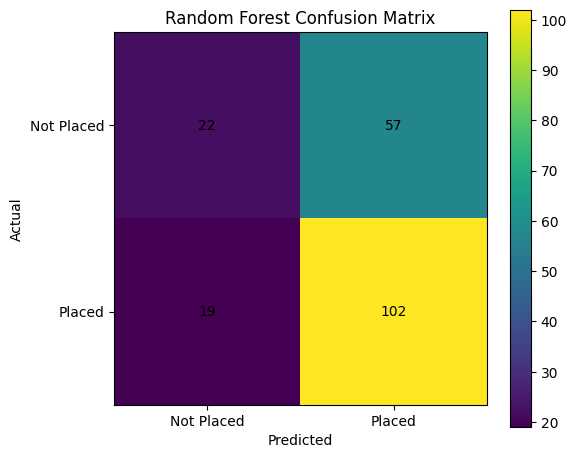

In [60]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [61]:
print("Minimum timestamp:", feature_data["event_timestamp"].min())
print("Maximum timestamp:", feature_data["event_timestamp"].max())

Minimum timestamp: 2026-01-01 00:00:00
Maximum timestamp: 2026-09-07 18:00:00


In [62]:
start_date = feature_data["event_timestamp"].min()
end_date = feature_data["event_timestamp"].max()

store.materialize(
    start_date=start_date,
    end_date=end_date
)

print("Materialization completed successfully!")

Materializing 1 feature views from 2026-01-01 00:00:00+00:00 to 2026-09-07 18:00:00+00:00 into the sqlite online store.

graduate_skill_features:
Materialization completed successfully!


In [63]:
student_id = feature_data["REG_Number"].iloc[0]

print("Student selected:", student_id)

Student selected: 231FA04001


In [64]:
online_features = store.get_online_features(
    features=feature_refs,
    entity_rows=[
        {
            "REG_Number": student_id
        }
    ]
).to_df()

print("Online feature retrieval completed!")

display(online_features)

Online feature retrieval completed!


,REG_Number,Python_Skill,CGPA,DSA_Skill,Skill_Alignment_Percentage,Communication_Skill,Internship_Months,SQL_Skill,OOP_Skill,Cloud_Computing_Skill,Problem_Solving_Skill,Employability_Score,Projects_Count,Overall_Skill_Gap,DBMS_Skill,Machine_Learning_Skill,High_Priority_Gap_Count,Certifications_Count
0,231FA04001,6.2,7.78,8.0,87.800003,6.7,0,4.7,7.8,7.6,5.3,64.970001,5,1.22,9.2,6.0,1,3


In [65]:
print("ONLINE FEATURE RETRIEVAL")
print("=" * 40)

display(
    online_features[
        [
            "REG_Number",
            "CGPA",
            "Python_Skill",
            "SQL_Skill",
            "DSA_Skill",
            "Overall_Skill_Gap",
            "Skill_Alignment_Percentage",
            "Employability_Score"
        ]
    ]
)

ONLINE FEATURE RETRIEVAL


,REG_Number,CGPA,Python_Skill,SQL_Skill,DSA_Skill,Overall_Skill_Gap,Skill_Alignment_Percentage,Employability_Score
0,231FA04001,7.78,6.2,4.7,8.0,1.22,87.800003,64.970001


In [66]:
prediction_data = online_features[feature_columns]

prediction = rf_model.predict(prediction_data)[0]

if prediction == 1:
    result = "Placed"
else:
    result = "Not Placed"

print("Student:", student_id)
print("Predicted Placement Status:", result)

Student: 231FA04001
Predicted Placement Status: Placed


In [67]:
probability = rf_model.predict_proba(prediction_data)[0]

print("Student:", student_id)
print("Prediction:", result)
print("Not Placed Probability:", round(probability[0], 4))
print("Placed Probability:", round(probability[1], 4))

Student: 231FA04001
Prediction: Placed
Not Placed Probability: 0.21
Placed Probability: 0.79
